# Non-prismatic Elements and Imposed Curvature

`PyCBA` extends the classical prismatic continuous-beam analysis with two
independent features:

- a **non-prismatic (variable-$EI$) element** &mdash; a member whose flexural
  rigidity $EI(x)$ varies along its length (a haunch, taper or step), defined by
  a `SectionEI` object. This is an *element*.
- an **imposed-curvature load** &mdash; a free (stress-free) curvature field
  applied along a member to model creep, shrinkage or thermal effects, added
  with `BeamAnalysis.add_ic`. This is a *loading*.

Examples 1&ndash;2 cover the element, Example 3 the loading, and Example 4
combines them. The underlying force-method formulation is given in the
[Theoretical Basis](../theory.ipynb); the source texts are listed on the
[References](../references.rst) page.

In [1]:
import pycba as cba
import numpy as np
import matplotlib.pyplot as plt
from pycba import SectionEI

## Example 1 - Building a variable-EI section

A non-prismatic member is described by a `SectionEI`
built from contiguous **segments** (`const`, `linear`, `pwl`, `poly`) giving
$EI(x)$ in the span-local coordinate. Here the member is stiff (haunched) at both
supports and slender at midspan. `SectionEI.plot()` draws $EI(x)$ so you can
check the section you built &mdash; kinks show as slope changes and the segment
joins are flagged.

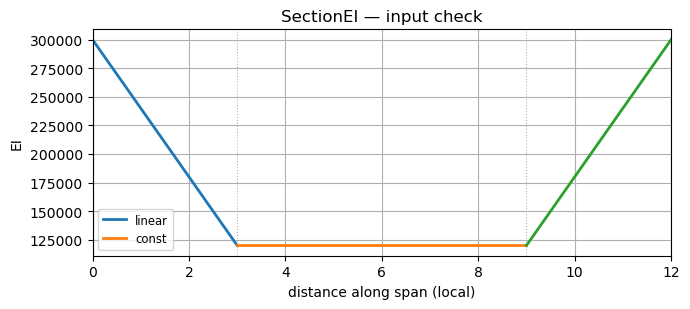

In [2]:
# Stiff (haunched) at both supports, slender at midspan: two linear haunches
# and a constant flat soffit.  SectionEI.plot() is an input-verification of EI(x).
sec = SectionEI(
    [
        ("linear", [0.0, 3.0], [3.0e5, 1.2e5]),   # haunch down from the left support
        ("const",  [3.0, 9.0], 1.2e5),            # slender flat soffit
        ("linear", [9.0, 12.0], [1.2e5, 3.0e5]),  # haunch up to the right support
    ]
)
fig, ax = sec.plot(figsize=(7, 3.2))
fig.tight_layout()

## Example 2 - Two-span beam with a haunched support

Haunching a continuous beam over its interior support stiffens the "pier" and
**attracts hogging moment to it**. Each span deepens parabolically toward the
interior support (so $EI$ rises there); we compare the pier moment with the
prismatic beam, whose value is the textbook $-wL^2/8$.

In [3]:
# Symmetric two-span beam; section depth deepens parabolically to the interior
# support, so EI = E*b*d(x)^3/12 rises toward the pier.
E, b = 30.0e6, 1.0                 # E = 30 GPa (kPa), unit width
Lsp, DC, Dh, Lh, w = 10.0, 0.6, 1.2, 3.0, 30.0   # span, mid depth, pier depth, haunch len, UDL
EI_const = E * b * DC**3 / 12.0    # prismatic (mid-depth) rigidity


def haunch_poly(d0, d1, x0, x1):
    """Parabolic depth d0->d1 over [x0, x1] as an EI(x) = E*b*d(x)^3/12 callable."""
    def f(x):
        s = (np.asarray(x, float) - x0) / (x1 - x0)
        return E * b * (d0 + (d1 - d0) * s**2) ** 3 / 12.0
    return f


# span 1: prismatic at the end support, haunch deepening to the pier (right end)
sec1 = SectionEI(
    [
        ("const", [0.0, Lsp - Lh], EI_const),
        ("poly",  [Lsp - Lh, Lsp], haunch_poly(DC, Dh, Lsp - Lh, Lsp), 6),
    ]
)
# span 2: mirror image -- haunch at the pier (left end), prismatic to the right
sec2 = SectionEI(
    [
        ("poly",  [0.0, Lh], haunch_poly(Dh, DC, 0.0, Lh), 6),
        ("const", [Lh, Lsp], EI_const),
    ]
)

ba_h = cba.BeamAnalysis([Lsp, Lsp], [sec1, sec2], [-1, 0, -1, 0, -1, 0])
ba_h.add_udl(1, w)
ba_h.add_udl(2, w)
ba_h.analyze(npts=300)
M_pier_h = ba_h.beam_results.results.M.min()

ba_p = cba.BeamAnalysis([Lsp, Lsp], [EI_const, EI_const], [-1, 0, -1, 0, -1, 0])
ba_p.add_udl(1, w)
ba_p.add_udl(2, w)
ba_p.analyze(npts=300)
M_pier_p = ba_p.beam_results.results.M.min()

print(f"Prismatic pier moment = {M_pier_p:8.1f} kNm  (closed form -wL^2/8 = {-w*Lsp**2/8:.1f})")
print(f"Haunched  pier moment = {M_pier_h:8.1f} kNm  "
      f"({100*(abs(M_pier_h)-abs(M_pier_p))/abs(M_pier_p):+.0f}% -- haunch draws hogging to the pier)")

Prismatic pier moment =   -375.0 kNm  (closed form -wL^2/8 = -375.0)
Haunched  pier moment =   -532.4 kNm  (+42% -- haunch draws hogging to the pier)


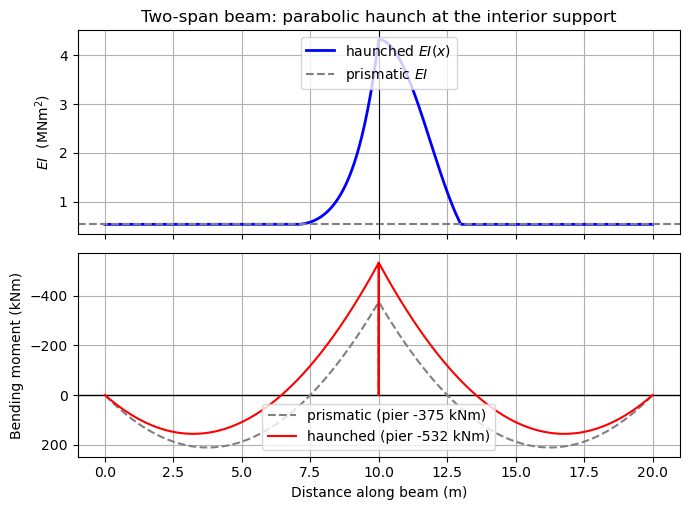

In [4]:
# EI(x) elevation and the resulting BMD (haunched vs prismatic).
xx = np.linspace(0.0, Lsp, 200)
EI_prof = np.concatenate([sec1(xx), sec2(xx)]) / 1e6          # MNm^2
x_prof = np.concatenate([xx, Lsp + xx])

fig, axs = plt.subplots(2, 1, figsize=(7, 5.2), sharex=True)
axs[0].plot(x_prof, EI_prof, "b", lw=2, label="haunched $EI(x)$")
axs[0].axhline(EI_const / 1e6, color="0.5", ls="--", lw=1.5, label="prismatic $EI$")
axs[0].axvline(Lsp, color="k", lw=0.8)
axs[0].set_ylabel("$EI$  (MNm$^2$)")
axs[0].set_title("Two-span beam: parabolic haunch at the interior support")
axs[0].grid(True)
axs[0].legend(loc="upper center")

axs[1].axhline(0, color="k", lw=1.0)
axs[1].plot(ba_p.beam_results.results.x, ba_p.beam_results.results.M, "0.5", ls="--",
            label=f"prismatic (pier {M_pier_p:.0f} kNm)")
axs[1].plot(ba_h.beam_results.results.x, ba_h.beam_results.results.M, "r",
            label=f"haunched (pier {M_pier_h:.0f} kNm)")
axs[1].invert_yaxis()
axs[1].set_ylabel("Bending moment (kNm)")
axs[1].set_xlabel("Distance along beam (m)")
axs[1].grid(True)
axs[1].legend(loc="lower center")
fig.tight_layout()

## Example 3 - Imposed curvature on a continuous beam

An imposed curvature is *self-strained*: on a simply-supported span it produces
deflection but no reactions. On a **continuous** beam the restraint of the free
curvature generates real moments. For two equal spans under a uniform curvature
$\kappa$ the interior-support moment is $-1.5\,EI\kappa$ and the system is
self-equilibrating (zero net reaction).

In [5]:
# A uniform free curvature kappa on each span (e.g. shrinkage / thermal).
L, EI, kappa = 10.0, 180000.0, 1e-4
ba = cba.BeamAnalysis([L, L], EI, [-1, 0, -1, 0, -1, 0])
ba.add_ic(1, kappa)
ba.add_ic(2, kappa)
ba.analyze(npts=301)

res = ba.beam_results.results
M_pier = res.M[np.argmin(np.abs(res.x - L))]
print(f"Interior-support moment = {M_pier:7.2f} kNm  (closed form -1.5 EI k = {-1.5*EI*kappa:.2f})")
print(f"Sum of reactions        = {np.sum(ba.beam_results.R):+.2e} kN  (self-equilibrating)")

Interior-support moment =  -27.00 kNm  (closed form -1.5 EI k = -27.00)
Sum of reactions        = +0.00e+00 kN  (self-equilibrating)


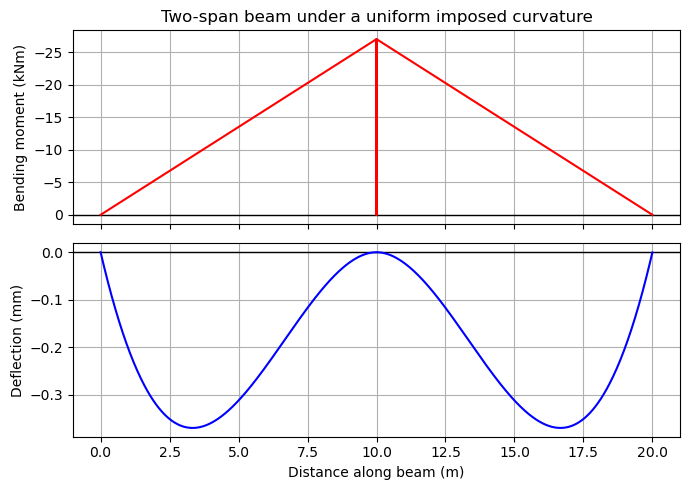

In [6]:
# Bending moment and deflected shape under the imposed curvature.
fig, axs = plt.subplots(2, 1, figsize=(7, 5), sharex=True)
axs[0].axhline(0, color="k", lw=1.0)
axs[0].plot(res.x, res.M, "r")
axs[0].invert_yaxis()
axs[0].set_ylabel("Bending moment (kNm)")
axs[0].set_title("Two-span beam under a uniform imposed curvature")
axs[0].grid(True)

axs[1].axhline(0, color="k", lw=1.0)
axs[1].plot(res.x, res.D * 1e3, "b")
axs[1].set_ylabel("Deflection (mm)")
axs[1].set_xlabel("Distance along beam (m)")
axs[1].grid(True)
fig.tight_layout()

## Example 4 - Imposed curvature on a non-prismatic member

The two features combine naturally: an imposed curvature applied to a
`SectionEI` member. The fixed-end forces are integrated across the section
breakpoints, so the variable rigidity is honoured exactly. Here the haunched
two-span beam of Example 2 carries the uniform curvature of Example 3 &mdash; the
stiffer pier now attracts a larger restraint moment than the prismatic beam.

In [7]:
# The haunched two-span beam of Example 2, now under the imposed curvature of
# Example 3 instead of a UDL: curvature on a non-prismatic member.
ba_np = cba.BeamAnalysis([Lsp, Lsp], [sec1, sec2], [-1, 0, -1, 0, -1, 0])
ba_np.add_ic(1, kappa)
ba_np.add_ic(2, kappa)
ba_np.analyze(npts=300)
M_pier_np = ba_np.beam_results.results.M.min()

# prismatic reference at the mid-depth rigidity
ba_npp = cba.BeamAnalysis([Lsp, Lsp], [EI_const, EI_const], [-1, 0, -1, 0, -1, 0])
ba_npp.add_ic(1, kappa)
ba_npp.add_ic(2, kappa)
ba_npp.analyze(npts=300)
M_pier_npp = ba_npp.beam_results.results.M.min()

print(f"Prismatic pier moment = {M_pier_npp:7.2f} kNm  (closed form -1.5 EI k = {-1.5*EI_const*kappa:.2f})")
print(f"Haunched  pier moment = {M_pier_np:7.2f} kNm  (stiffer pier draws more restraint moment)")
print(f"Sum of reactions      = {np.sum(ba_np.beam_results.R):+.2e} kN  (still self-equilibrating)")

Prismatic pier moment =  -81.00 kNm  (closed form -1.5 EI k = -81.00)
Haunched  pier moment = -139.03 kNm  (stiffer pier draws more restraint moment)
Sum of reactions      = +0.00e+00 kN  (still self-equilibrating)


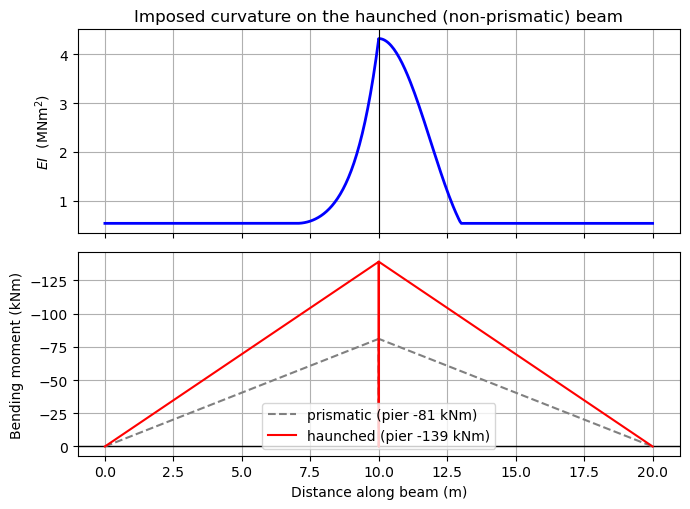

In [8]:
# EI(x) elevation and the resulting BMD (haunched vs prismatic).
xx = np.linspace(0.0, Lsp, 200)
EI_prof = np.concatenate([sec1(xx), sec2(xx)]) / 1e6
x_prof = np.concatenate([xx, Lsp + xx])

fig, axs = plt.subplots(2, 1, figsize=(7, 5.2), sharex=True)
axs[0].plot(x_prof, EI_prof, "b", lw=2)
axs[0].axvline(Lsp, color="k", lw=0.8)
axs[0].set_ylabel("$EI$  (MNm$^2$)")
axs[0].set_title("Imposed curvature on the haunched (non-prismatic) beam")
axs[0].grid(True)

axs[1].axhline(0, color="k", lw=1.0)
axs[1].plot(ba_npp.beam_results.results.x, ba_npp.beam_results.results.M, "0.5", ls="--",
            label=f"prismatic (pier {M_pier_npp:.0f} kNm)")
axs[1].plot(ba_np.beam_results.results.x, ba_np.beam_results.results.M, "r",
            label=f"haunched (pier {M_pier_np:.0f} kNm)")
axs[1].invert_yaxis()
axs[1].set_ylabel("Bending moment (kNm)")
axs[1].set_xlabel("Distance along beam (m)")
axs[1].grid(True)
axs[1].legend(loc="lower center")
fig.tight_layout()